# Détection de Spam SMS 
### Dataset : SMS Spam Collection (UCI) | Visualisations Seaborn & Matplotlib

| + | Étape | Question |
|---|-------|---------|
| 1 | **Data Selection** | Quelles données pour quel problème ? |
| 2 | **Data Cleaning** | Les données sont-elles exploitables ? |
| 3 | **Data Mining (EDA)** | Qu'est-ce que les données nous révèlent ? |
| 4 | **Feature Selection** | Quelles variables sont vraiment utiles ? |
| 5 | **Choix du modèle** | Quel algorithme est le plus performant ? |


##  Imports & Configuration globale

In [2]:
import os, re, string, warnings
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score
)
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
nltk.download("stopwords", quiet=True)
nltk.download("punkt",     quiet=True)

os.makedirs("output", exist_ok=True)

# ── Style global Seaborn ──────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
PALETTE = {"ham": "#378ADD", "spam": "#D85A30"}
plt.rcParams.update({"figure.dpi": 130, "figure.facecolor": "white"})

print("Imports OK")
print(f"   pandas {pd.__version__} | seaborn {sns.__version__} | sklearn {__import__('sklearn').__version__}")


Imports OK
   pandas 2.3.3 | seaborn 0.13.2 | sklearn 1.8.0


---
# Étape 1 — Data Selection
> **Question :** *Quelles données pour quel problème ?*

### Pourquoi ce dataset ?
Le **SMS Spam Collection (UCI)** contient 5 572 vrais SMS étiquetés manuellement.  
C'est le standard académique mondial pour la détection de spam textuel.

| Critère | Détail |
|---------|--------|
| Source | UCI Machine Learning Repository |
| Format | TSV — séparé par tabulation `\t` |
| Taille | 5 572 messages |
| Labels | `ham` (légitime) / `spam` |

 `sep='\t'` obligatoire — ce n'est **pas** un CSV classique.


In [3]:
# ── Chargement ────────────────────────────────────────────
df_raw = pd.read_csv(
    os.path.join(os.getcwd(), "data", "SMSSpamCollection"),
    sep="\t",
    header=None,
    names=["label", "message"],
    encoding="latin-1"
)

print("=" * 52)
print("  ÉTAPE 1 — DATA SELECTION")
print("=" * 52)
print(f"\n {df_raw.shape[0]} messages chargés — {df_raw.shape[1]} colonnes")
print(f"   Valeurs nulles : {df_raw.isnull().sum().sum()}")
print(f"   Doublons      : {df_raw.duplicated().sum()}")
df_raw.head(6)


  ÉTAPE 1 — DATA SELECTION

 5572 messages chargés — 2 colonnes
   Valeurs nulles : 0
   Doublons      : 403


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...


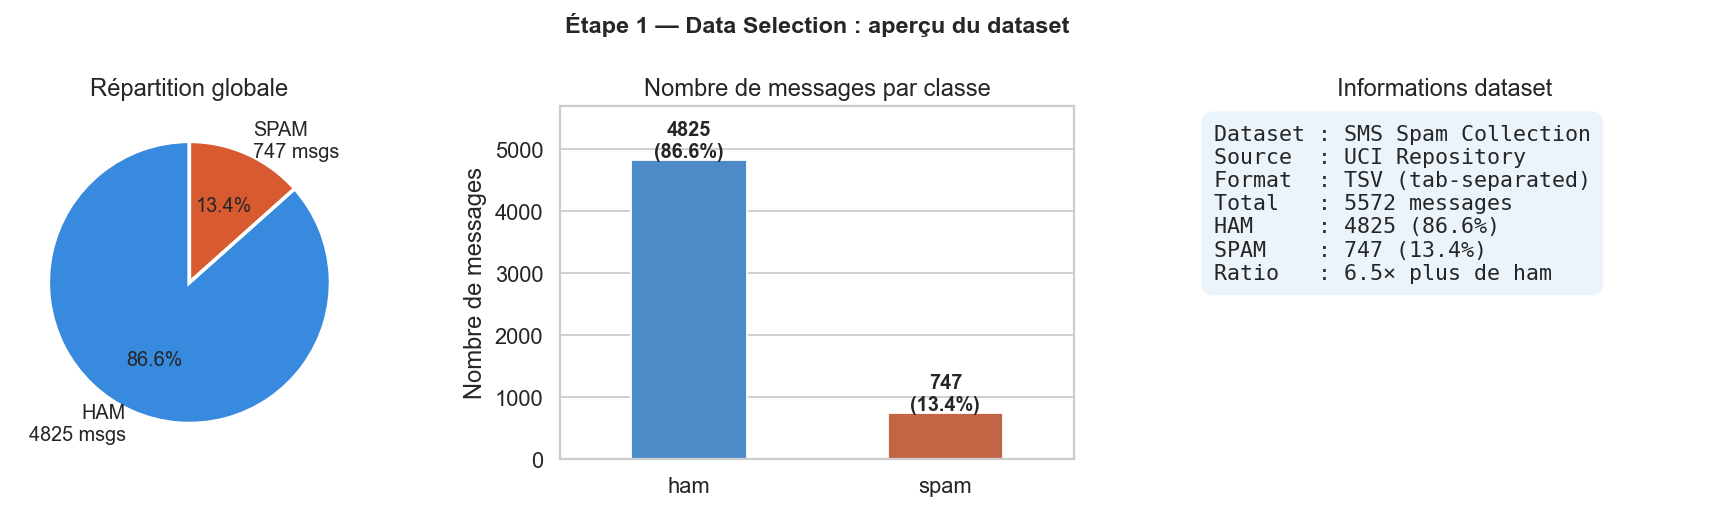


HAM : 4825 messages (86.6%) — large majorité du dataset

SPAM : 747 messages (13.4%) — minorité, 6.5× moins nombreux que les ham

Synthèse : dataset déséquilibré → privilégier F1-Score et ROC-AUC plutôt que l'accuracy seule pour évaluer les modèles


In [4]:
# ── Visualisation 1 : Répartition des classes ─────────────
counts = df_raw["label"].value_counts()
pct    = counts / counts.sum() * 100

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Étape 1 — Data Selection : aperçu du dataset", fontsize=13, fontweight="bold")

# 1a. Camembert Seaborn / matplotlib
wedges, texts, autotexts = axes[0].pie(
    counts.values,
    labels=[f"{l.upper()}\n{v} msgs" for l, v in counts.items()],
    colors=list(PALETTE.values()),
    autopct="%1.1f%%", startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=2),
    textprops=dict(fontsize=11)
)
axes[0].set_title("Répartition globale")

# 1b. Barplot Seaborn
sns.barplot(x=counts.index, y=counts.values, palette=PALETTE, ax=axes[1], width=0.45)
axes[1].set_title("Nombre de messages par classe")
axes[1].set_ylabel("Nombre de messages")
axes[1].set_xlabel("")
for i, (v, p) in enumerate(zip(counts.values, pct.values)):
    axes[1].text(i, v + 40, f"{v}\n({p:.1f}%)", ha="center", fontweight="bold", fontsize=11)
axes[1].set_ylim(0, max(counts.values) * 1.18)

# 1c. Info dataset
info_txt = (
    f"Dataset : SMS Spam Collection\n"
    f"Source  : UCI Repository\n"
    f"Format  : TSV (tab-separated)\n"
    f"Total   : {len(df_raw)} messages\n"
    f"HAM     : {counts['ham']} ({pct['ham']:.1f}%)\n"
    f"SPAM    : {counts['spam']} ({pct['spam']:.1f}%)\n"
    f"Ratio   : {counts['ham']/counts['spam']:.1f}× plus de ham"
)
axes[2].axis("off")
axes[2].text(0.05, 0.95, info_txt, transform=axes[2].transAxes,
             fontsize=12, verticalalignment="top", fontfamily="monospace",
             bbox=dict(boxstyle="round,pad=0.6", facecolor="#E6F1FB", alpha=0.8))
axes[2].set_title("Informations dataset")

plt.tight_layout()
plt.savefig("output/01_data_selection.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nHAM : 4825 messages (86.6%) — large majorité du dataset")
print("\nSPAM : 747 messages (13.4%) — minorité, 6.5× moins nombreux que les ham")
print("\nSynthèse : dataset déséquilibré → privilégier F1-Score et ROC-AUC plutôt que l'accuracy seule pour évaluer les modèles")


---
#  Étape 2 — Data Cleaning
> **Question :** *Les données sont-elles exploitables ?*

### Pipeline de nettoyage en 5 sous-étapes
```
Texte brut
  ↓  1. Minuscules          "FREE PRIZE" → "free prize"
  ↓  2. Supprimer chiffres  "call 0800"  → "call"
  ↓  3. Supprimer ponct.    "win!!!"     → "win"
  ↓  4. Supprimer stopwords "you have won" → "won"
  ↓  5. Stemming (NLTK)     "winning"    → "win"
Texte propre → prêt pour la vectorisation
```


In [5]:
# ── Fonction de nettoyage ─────────────────────────────────
stemmer    = PorterStemmer()
stop_words = set(stopwords.words("english"))

def clean_text(text: str) -> str:
    text   = text.lower()
    text   = re.sub(r"\d+", " ", text)
    text   = text.translate(str.maketrans("", "", string.punctuation))
    tokens = [stemmer.stem(t) for t in text.split()
              if t not in stop_words and len(t) > 2]
    return " ".join(tokens)

# ── Démonstration étape par étape ─────────────────────────
print("=" * 52)
print("  ÉTAPE 2 — DATA CLEANING")
print("=" * 52)

exemples = [
    ("SPAM", "WINNER!! You've been selected. Call now to claim your £1000 FREE prize!"),
    ("HAM",  "Hey, are you coming to the study group tomorrow at 6pm?"),
]
for lbl, msg in exemples:
    e1 = msg.lower()
    e2 = re.sub(r"\d+", " ", e1)
    e3 = e2.translate(str.maketrans("", "", string.punctuation))
    e4 = [t for t in e3.split() if t not in stop_words and len(t) > 2]
    e5 = [stemmer.stem(t) for t in e4]
    print(f"\n[{lbl}] {msg[:60]}")
    print(f"  1. Minusc.   → {e1[:60]}")
    print(f"  2. Chiffres  → {e2[:60]}")
    print(f"  3. Ponct.    → {e3[:60]}")
    print(f"  4. Stopwords → {e4[:7]}")
    print(f"  5. Stemming  → {e5[:7]}")
    print(f"  Résultat  → '{clean_text(msg)}'")


  ÉTAPE 2 — DATA CLEANING

[SPAM] WINNER!! You've been selected. Call now to claim your £1000 
  1. Minusc.   → winner!! you've been selected. call now to claim your £1000 
  2. Chiffres  → winner!! you've been selected. call now to claim your £  fre
  3. Ponct.    → winner youve been selected call now to claim your £  free pr
  4. Stopwords → ['winner', 'youve', 'selected', 'call', 'claim', 'free', 'prize']
  5. Stemming  → ['winner', 'youv', 'select', 'call', 'claim', 'free', 'prize']
  Résultat  → 'winner youv select call claim free prize'

[HAM] Hey, are you coming to the study group tomorrow at 6pm?
  1. Minusc.   → hey, are you coming to the study group tomorrow at 6pm?
  2. Chiffres  → hey, are you coming to the study group tomorrow at  pm?
  3. Ponct.    → hey are you coming to the study group tomorrow at  pm
  4. Stopwords → ['hey', 'coming', 'study', 'group', 'tomorrow']
  5. Stemming  → ['hey', 'come', 'studi', 'group', 'tomorrow']
  Résultat  → 'hey come studi group tomorro

 5572 messages nettoyés


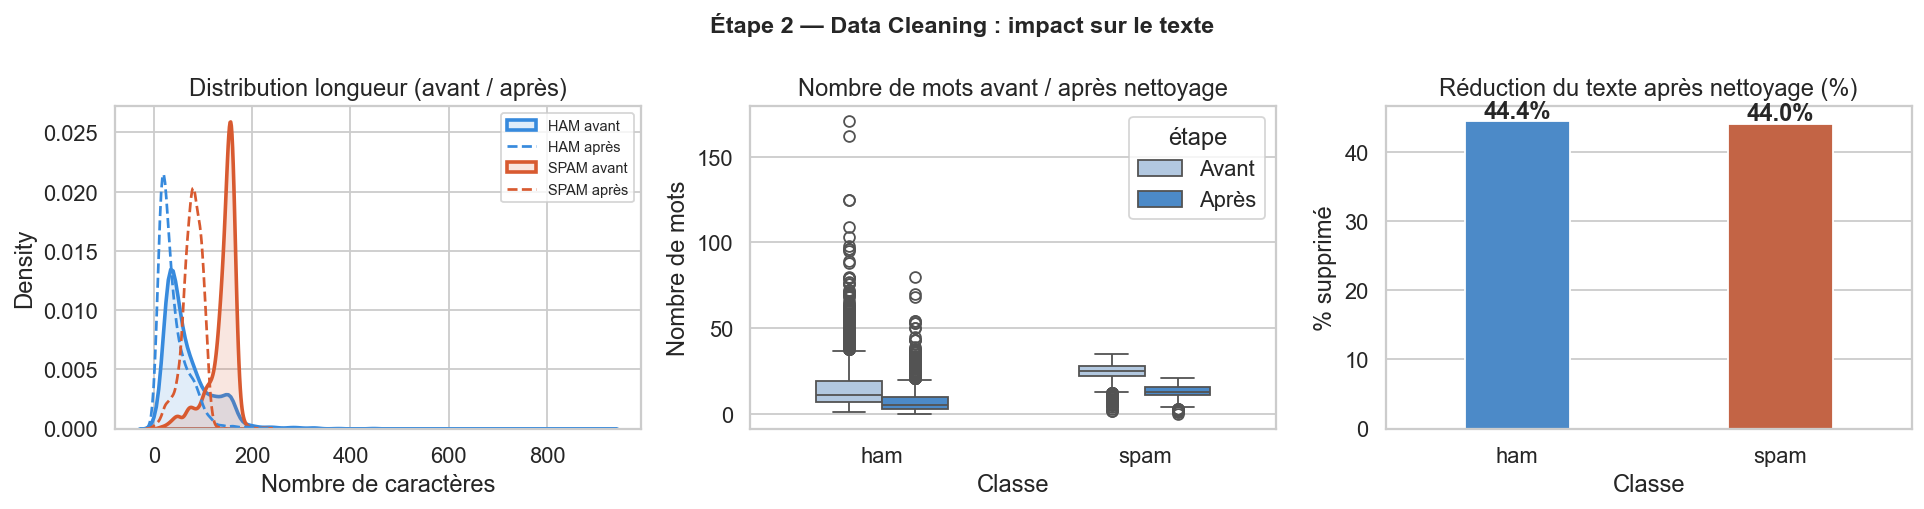


Synthèse : les spams sont naturellement plus longs que les ham, et le nettoyage réduit la dispersion des deux classes, surtout celle du spam

Synthèse : le nettoyage réduit le nombre de mots dans les deux classes, mais les spams restent globalement plus riches en mots que les ham même après traitement

montre que le nettoyage (stopwords, ponctuation, etc.) est appliqué de façon cohérente

📌 Réduction globale : 44% du texte supprimé (bruit)
   Avant : 81 car. → Après : 45 car.


In [6]:
# ── Application sur le dataset complet ────────────────────
df = df_raw.copy()
df["label_num"]     = df["label"].map({"ham": 0, "spam": 1})
df["clean_message"] = df["message"].apply(clean_text)
df["msg_length"]    = df["message"].apply(len)
df["clean_length"]  = df["clean_message"].apply(len)
df["word_count"]    = df["message"].apply(lambda x: len(x.split()))
df["clean_words"]   = df["clean_message"].apply(lambda x: len(x.split()))

print(f" {len(df)} messages nettoyés")

# ── Visualisation 2 : Impact du nettoyage ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Étape 2 — Data Cleaning : impact sur le texte", fontsize=13, fontweight="bold")

# 2a. Distribution longueur AVANT vs APRÈS — Seaborn KDE
for lbl, c in PALETTE.items():
    subset = df[df["label"] == lbl]
    sns.kdeplot(subset["msg_length"],   ax=axes[0], color=c, linewidth=2,
                label=f"{lbl.upper()} avant", fill=True, alpha=0.15)
    sns.kdeplot(subset["clean_length"], ax=axes[0], color=c, linewidth=1.5,
                label=f"{lbl.upper()} après", linestyle="--")
axes[0].set_title("Distribution longueur (avant / après)")
axes[0].set_xlabel("Nombre de caractères")
axes[0].legend(fontsize=8)

# 2b. Boxplot mots par classe — Seaborn
df_melt = pd.melt(df, id_vars="label",
                  value_vars=["word_count", "clean_words"],
                  var_name="étape", value_name="nb_mots")
df_melt["étape"] = df_melt["étape"].map({"word_count": "Avant", "clean_words": "Après"})
sns.boxplot(data=df_melt, x="label", y="nb_mots", hue="étape",
            palette=["#aac8e8","#378ADD"], ax=axes[1], width=0.5)
axes[1].set_title("Nombre de mots avant / après nettoyage")
axes[1].set_xlabel("Classe")
axes[1].set_ylabel("Nombre de mots")

# 2c. Réduction en % par classe
reduc = df.groupby("label").apply(
    lambda g: (1 - g["clean_length"].mean() / g["msg_length"].mean()) * 100
).reset_index()
reduc.columns = ["label", "reduction_pct"]
sns.barplot(data=reduc, x="label", y="reduction_pct", palette=PALETTE, ax=axes[2], width=0.4)
axes[2].set_title("Réduction du texte après nettoyage (%)")
axes[2].set_ylabel("% supprimé")
axes[2].set_xlabel("Classe")
for i, row in reduc.iterrows():
    axes[2].text(i, row["reduction_pct"] + 0.5, f"{row['reduction_pct']:.1f}%",
                 ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("output/02_data_cleaning.png", dpi=150, bbox_inches="tight")
plt.show()

red_global = (1 - df["clean_length"].mean() / df["msg_length"].mean()) * 100
print("\nSynthèse : les spams sont naturellement plus longs que les ham, et le nettoyage réduit la dispersion des deux classes, surtout celle du spam")
print("\nSynthèse : le nettoyage réduit le nombre de mots dans les deux classes, mais les spams restent globalement plus riches en mots que les ham même après traitement")
print("\nmontre que le nettoyage (stopwords, ponctuation, etc.) est appliqué de façon cohérente")
print(f"\nRéduction globale : {red_global:.0f}% du texte supprimé (bruit)")
print(f"   Avant : {df['msg_length'].mean():.0f} car. → Après : {df['clean_length'].mean():.0f} car.")


---
# Étape 3 — Data Mining (EDA)
> **Question :** *Qu'est-ce que les données nous révèlent ?*

### Patterns à découvrir
On cherche des **signaux discriminants** entre spam et ham :
- Longueur des messages
- Présence de chiffres, majuscules, URLs, points d'exclamation
- Mots les plus fréquents dans chaque classe
- Corrélations entre les variables

> 87% ham / 13% spam → déséquilibre à prendre en compte dans l'évaluation.


In [7]:
# ── Features exploratives ─────────────────────────────────
df["has_number"]  = df["message"].str.contains(r"\d", regex=True).astype(int)
df["has_url"]     = df["message"].str.contains(r"http|www|\.com", case=False, regex=True).astype(int)
df["upper_ratio"] = df["message"].apply(lambda x: sum(1 for c in x if c.isupper()) / (len(x)+1))
df["exclaim"]     = df["message"].str.count("!")
df["has_free"]    = df["message"].str.lower().str.contains("free").astype(int)
df["has_win"]     = df["message"].str.lower().str.contains("win").astype(int)

print("=" * 52)
print("  ÉTAPE 3 — DATA MINING (EDA)")
print("=" * 52)
print("\n── Statistiques descriptives par classe ───────────")
stats = df.groupby("label")[[
    "msg_length","word_count","upper_ratio",
    "has_number","has_url","exclaim","has_free","has_win"
]].mean().round(3)
print(stats.T.to_string())


  ÉTAPE 3 — DATA MINING (EDA)

── Statistiques descriptives par classe ───────────
label           ham     spam
msg_length   71.559  139.119
word_count   14.310   23.912
upper_ratio   0.057    0.113
has_number    0.156    0.948
has_url       0.004    0.162
exclaim       0.177    0.730
has_free      0.014    0.266
has_win       0.014    0.134


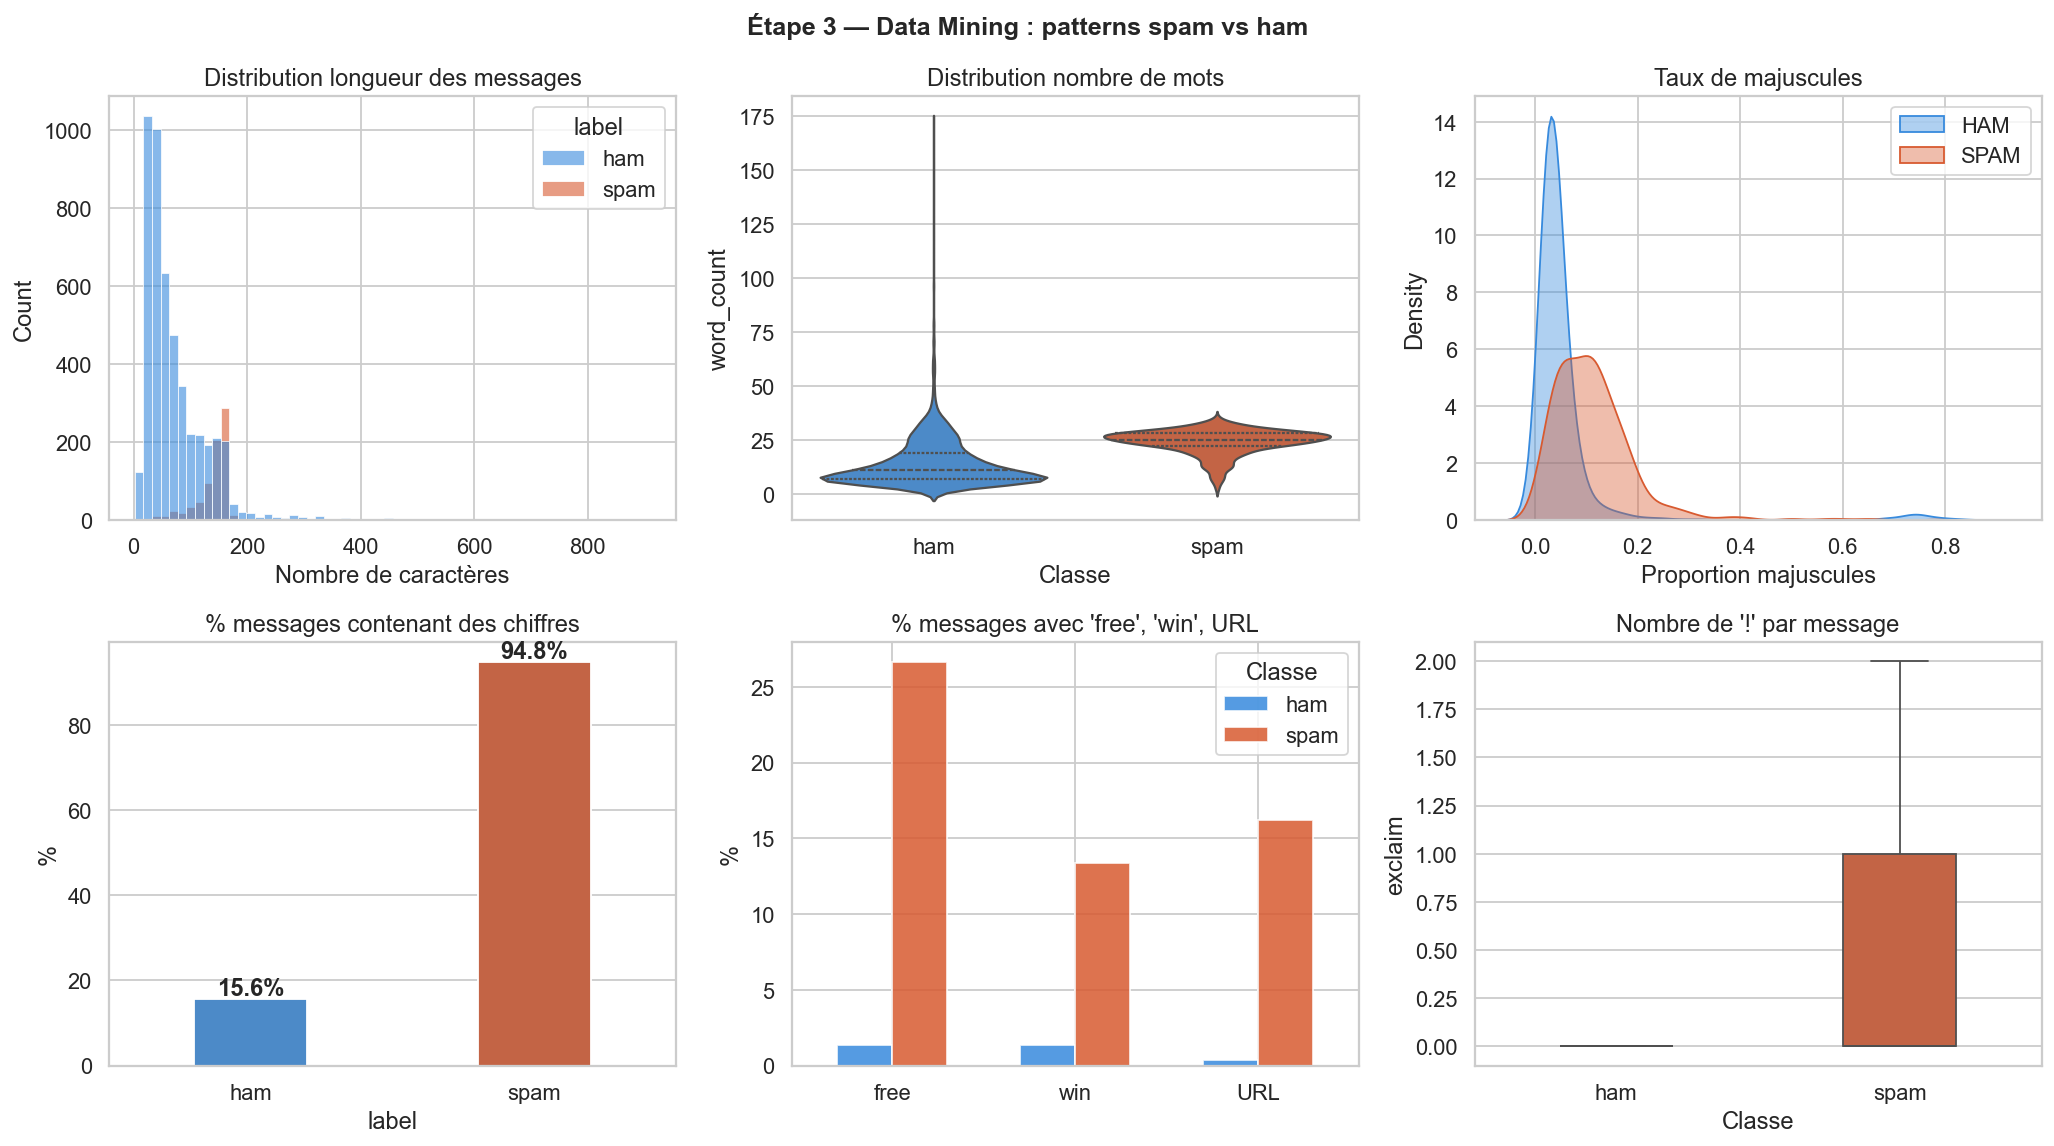

In [8]:
# ── Visualisation 3a : Distributions principales ──────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Étape 3 — Data Mining : patterns spam vs ham", fontsize=14, fontweight="bold")

# 3a-1. Histogramme longueur — Seaborn histplot
sns.histplot(data=df, x="msg_length", hue="label", bins=60,
             palette=PALETTE, alpha=0.6, ax=axes[0,0])
axes[0,0].set_title("Distribution longueur des messages")
axes[0,0].set_xlabel("Nombre de caractères")

# 3a-2. Violin plot nombre de mots
sns.violinplot(data=df, x="label", y="word_count", palette=PALETTE,
               inner="quartile", ax=axes[0,1])
axes[0,1].set_title("Distribution nombre de mots")
axes[0,1].set_xlabel("Classe")

# 3a-3. KDE taux de majuscules
for lbl, c in PALETTE.items():
    sns.kdeplot(df[df["label"]==lbl]["upper_ratio"],
                ax=axes[0,2], color=c, fill=True, alpha=0.4, label=lbl.upper())
axes[0,2].set_title("Taux de majuscules")
axes[0,2].set_xlabel("Proportion majuscules")
axes[0,2].legend()

# 3a-4. Barplot présence chiffres
pct_num = df.groupby("label")["has_number"].mean().reset_index()
pct_num["pct"] = pct_num["has_number"] * 100
sns.barplot(data=pct_num, x="label", y="pct", palette=PALETTE, ax=axes[1,0], width=0.4)
axes[1,0].set_title("% messages contenant des chiffres")
axes[1,0].set_ylabel("%")
for i, row in pct_num.iterrows():
    axes[1,0].text(i, row["pct"]+1, f"{row['pct']:.1f}%", ha="center", fontweight="bold")

# 3a-5. Barplot mots clés spam
feat_df = df.groupby("label")[["has_free","has_win","has_url"]].mean().mul(100)
feat_df.T.plot(kind="bar", ax=axes[1,1], color=list(PALETTE.values()), alpha=0.85, width=0.6)
axes[1,1].set_title("% messages avec 'free', 'win', URL")
axes[1,1].set_xticklabels(["free","win","URL"], rotation=0)
axes[1,1].set_ylabel("%")
axes[1,1].legend(title="Classe")

# 3a-6. Boxplot points d'exclamation
sns.boxplot(data=df, x="label", y="exclaim", palette=PALETTE,
            width=0.4, ax=axes[1,2], showfliers=False)
axes[1,2].set_title("Nombre de '!' par message")
axes[1,2].set_xlabel("Classe")

plt.tight_layout()
plt.savefig("output/03a_data_mining_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


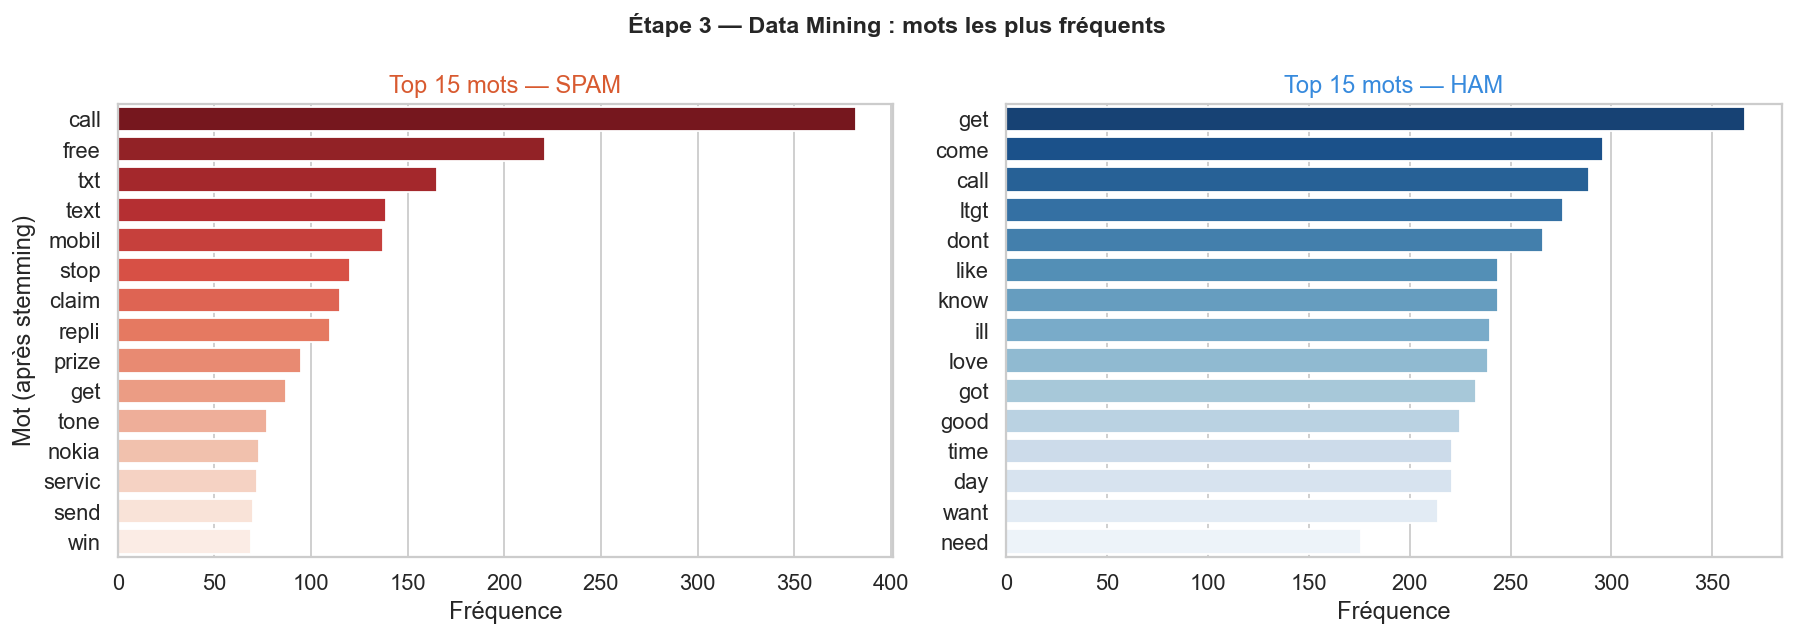

 SPAM : vocabulaire urgence/argent → ['call', 'free', 'txt', 'text', 'mobil', 'stop']
 HAM  : langage naturel quotidien  → ['get', 'come', 'call', 'ltgt', 'dont', 'like']


In [9]:
# ── Visualisation 3b : Top mots fréquents ─────────────────
def top_words(subset, n=15):
    words = " ".join(subset["clean_message"]).split()
    return pd.DataFrame(Counter(words).most_common(n), columns=["mot", "freq"])

top_spam = top_words(df[df["label"]=="spam"])
top_ham  = top_words(df[df["label"]=="ham"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Étape 3 — Data Mining : mots les plus fréquents", fontsize=13, fontweight="bold")

sns.barplot(data=top_spam, y="mot", x="freq", palette="Reds_r", ax=axes[0])
axes[0].set_title("Top 15 mots — SPAM", color="#D85A30")
axes[0].set_xlabel("Fréquence")
axes[0].set_ylabel("Mot (après stemming)")

sns.barplot(data=top_ham, y="mot", x="freq", palette="Blues_r", ax=axes[1])
axes[1].set_title("Top 15 mots — HAM", color="#378ADD")
axes[1].set_xlabel("Fréquence")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig("output/03b_data_mining_topwords.png", dpi=150, bbox_inches="tight")
plt.show()
print(" SPAM : vocabulaire urgence/argent →", top_spam["mot"].tolist()[:6])
print(" HAM  : langage naturel quotidien  →", top_ham["mot"].tolist()[:6])


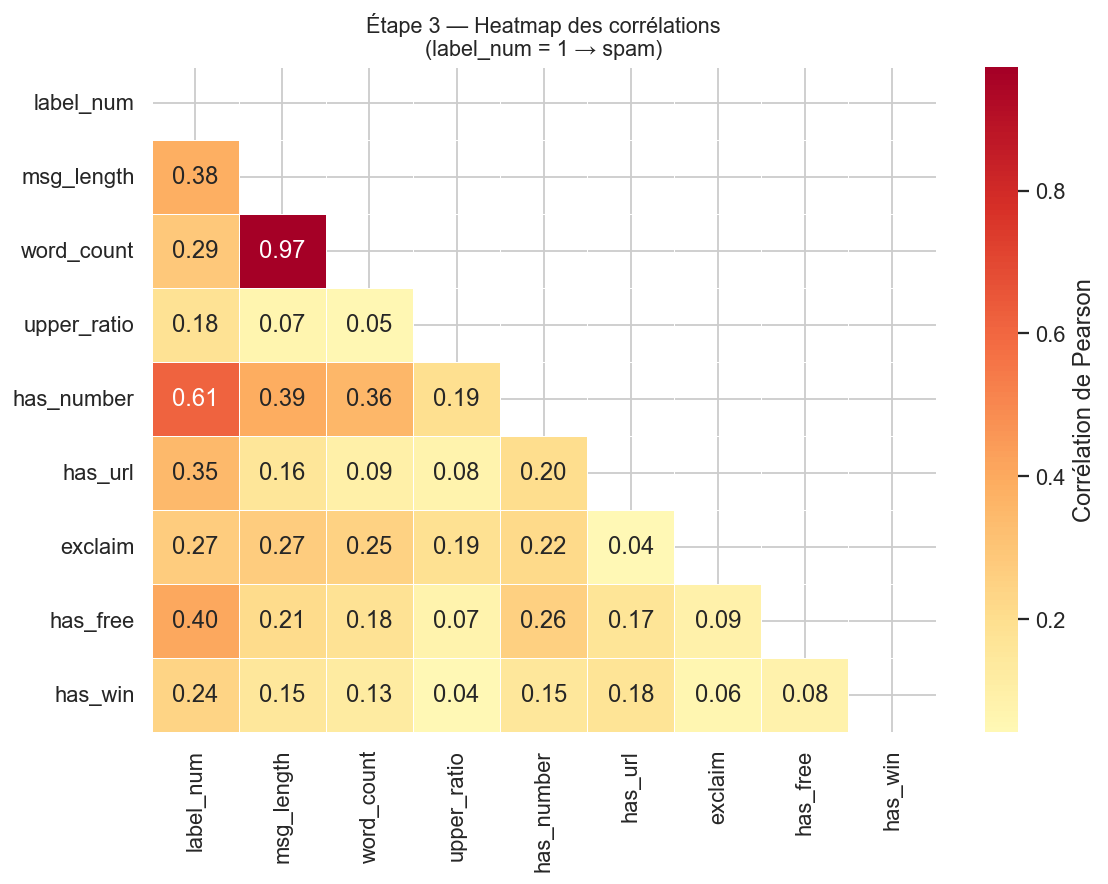

Variables les plus corrélées avec SPAM :
has_number     0.612728
has_free       0.404577
msg_length     0.383587
has_url        0.347395
word_count     0.286887
exclaim        0.274112
has_win        0.239757
upper_ratio    0.177610


In [10]:
# ── Visualisation 3c : Heatmap corrélations ───────────────
num_cols = ["label_num","msg_length","word_count",
            "upper_ratio","has_number","has_url","exclaim","has_free","has_win"]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="RdYlBu_r", center=0, linewidths=0.5,
            ax=ax, cbar_kws={"label": "Corrélation de Pearson"})
ax.set_title("Étape 3 — Heatmap des corrélations\n(label_num = 1 → spam)", fontsize=12)
plt.tight_layout()
plt.savefig("output/03c_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Variables les plus corrélées avec SPAM :")
corr_spam = corr["label_num"].drop("label_num").sort_values(ascending=False)
print(corr_spam.to_string())


---
#  Étape 4 — Feature Selection
> **Question :** *Quelles variables sont vraiment utiles ?*

### Stratégie : TF-IDF
On transforme chaque message en un **vecteur de scores numériques**.

$$TF\text{-}IDF(t, d) = TF(t,d) \times \log\left(\frac{N}{df(t)}\right)$$

| Paramètre | Valeur | Raison |
|-----------|--------|--------|
| `max_features` | 5 000 | Top 5 000 termes discriminants |
| `ngram_range` | (1, 2) | Capturer "free prize" en plus de "free" |
| `min_df` | 2 | Supprimer les termes hapax (bruit) |
| `sublinear_tf` | True | log(TF) pour équilibrer les fréquences |


In [11]:
# ── Split train / test stratifié ──────────────────────────
print("=" * 52)
print("  ÉTAPE 4 — FEATURE SELECTION")
print("=" * 52)

X = df["clean_message"]
y = df["label_num"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"\n Split stratifié :")
print(f"   Train : {len(X_train)} msgs  — {y_train.mean()*100:.1f}% spam")
print(f"   Test  : {len(X_test)}  msgs  — {y_test.mean()*100:.1f}% spam")


  ÉTAPE 4 — FEATURE SELECTION

 Split stratifié :
   Train : 4457 msgs  — 13.4% spam
   Test  : 1115  msgs  — 13.4% spam


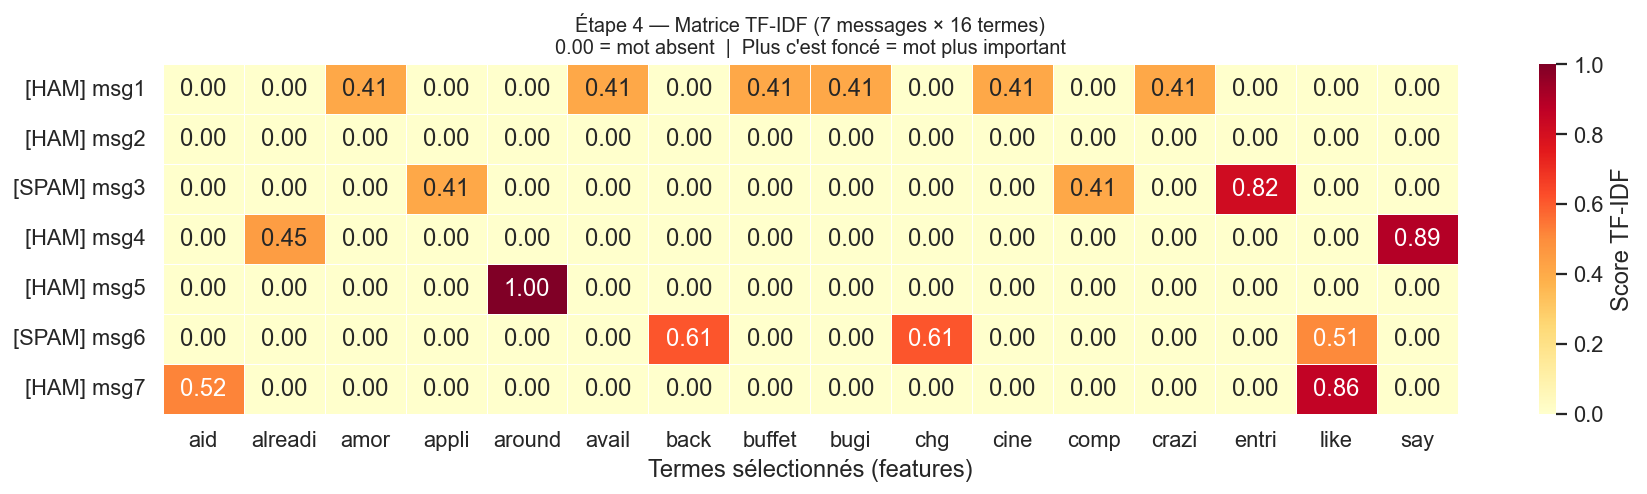

In [12]:
# ── Visualisation 4a : Matrice TF-IDF ────────────────────
demo_msgs   = df["clean_message"].head(7).tolist()
demo_labels = df["label"].head(7).tolist()

vec_demo = TfidfVectorizer(max_features=16)
mat_demo = vec_demo.fit_transform(demo_msgs)

df_tfidf = pd.DataFrame(
    mat_demo.toarray().round(3),
    columns=vec_demo.get_feature_names_out(),
    index=[f"[{l.upper()}] msg{i+1}" for i, l in enumerate(demo_labels)]
)

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(df_tfidf, annot=True, fmt=".2f", cmap="YlOrRd",
            linewidths=0.4, ax=ax,
            cbar_kws={"label": "Score TF-IDF"})
ax.set_title("Étape 4 — Matrice TF-IDF (7 messages × 16 termes)\n"
             "0.00 = mot absent  |  Plus c'est foncé = mot plus important", fontsize=11)
ax.set_xlabel("Termes sélectionnés (features)")
plt.tight_layout()
plt.savefig("output/04a_tfidf_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


 Vectorisation TF-IDF terminée
   Matrice train : (4457, 5000)
   Matrice test  : (1115, 5000)
   Densité       : 0.17% (matrice creuse)


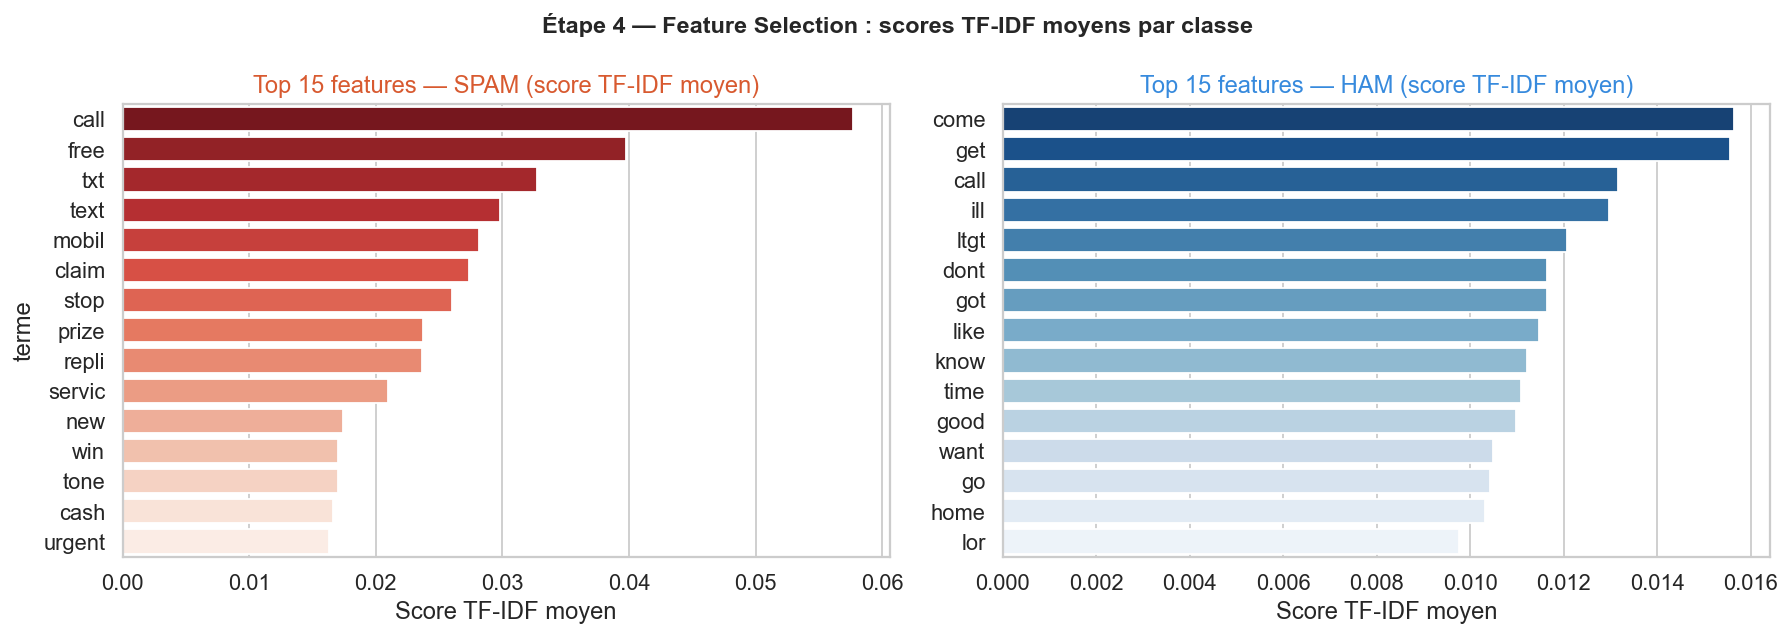

In [13]:
# ── Vectorisation finale TF-IDF ───────────────────────────
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)
features    = vectorizer.get_feature_names_out()

print(f" Vectorisation TF-IDF terminée")
print(f"   Matrice train : {X_train_vec.shape}")
print(f"   Matrice test  : {X_test_vec.shape}")
print(f"   Densité       : {X_train_vec.nnz/(X_train_vec.shape[0]*X_train_vec.shape[1])*100:.2f}% (matrice creuse)")

# ── Visualisation 4b : Scores TF-IDF par classe ───────────
spam_msgs = df[df["label"]=="spam"]["clean_message"]
ham_msgs  = df[df["label"]=="ham"]["clean_message"]

vec_cls = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=2, sublinear_tf=True)
vec_cls.fit(df["clean_message"])
spam_vec = vec_cls.transform(spam_msgs)
ham_vec  = vec_cls.transform(ham_msgs)

feat_names = vec_cls.get_feature_names_out()
spam_mean  = np.asarray(spam_vec.mean(axis=0)).flatten()
ham_mean   = np.asarray(ham_vec.mean(axis=0)).flatten()

top_idx_spam = np.argsort(spam_mean)[-15:][::-1]
top_idx_ham  = np.argsort(ham_mean)[-15:][::-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Étape 4 — Feature Selection : scores TF-IDF moyens par classe", fontsize=13, fontweight="bold")

df_spam_feat = pd.DataFrame({"terme": feat_names[top_idx_spam], "score": spam_mean[top_idx_spam]})
df_ham_feat  = pd.DataFrame({"terme": feat_names[top_idx_ham],  "score": ham_mean[top_idx_ham]})

sns.barplot(data=df_spam_feat, y="terme", x="score", palette="Reds_r",  ax=axes[0])
axes[0].set_title("Top 15 features — SPAM (score TF-IDF moyen)", color="#D85A30")
axes[0].set_xlabel("Score TF-IDF moyen")

sns.barplot(data=df_ham_feat, y="terme", x="score", palette="Blues_r", ax=axes[1])
axes[1].set_title("Top 15 features — HAM (score TF-IDF moyen)", color="#378ADD")
axes[1].set_xlabel("Score TF-IDF moyen")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig("output/04b_tfidf_features.png", dpi=150, bbox_inches="tight")
plt.show()


---
# Étape 5 — Choix du Modèle
> **Question :** *Quel algorithme est le plus performant sur ces données ?*

### Stratégie en 4 phases
1. Entraîner **3 modèles candidats**
2. Comparer sur **métriques multiples** (Accuracy, F1, Precision, Recall)
3. Visualiser **matrice de confusion** et **courbe ROC**
4. Optimiser avec **GridSearchCV**

### Les 3 modèles
| Modèle | Type | Avantage |
|--------|------|----------|
| **Naive Bayes** | Probabiliste | Rapide, conçu pour le texte |
| **Logistic Regression** | Linéaire | Probabilités calibrées |
| **Linear SVC** | Marge maximale | Souvent le plus précis sur texte |


In [14]:
# ── Entraînement des 3 modèles ────────────────────────────
print("=" * 52)
print("  ÉTAPE 5 — CHOIX DU MODÈLE")
print("=" * 52)

models = {
    "Naive Bayes": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1,2),
                                  sublinear_tf=True, min_df=2)),
        ("clf",   MultinomialNB(alpha=0.1))
    ]),
    "Logistic Regression": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1,2),
                                  sublinear_tf=True, min_df=2)),
        ("clf",   LogisticRegression(max_iter=1000, C=1.0, random_state=42))
    ]),
    "Linear SVC": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1,2),
                                  sublinear_tf=True, min_df=2)),
        ("clf",   LinearSVC(C=1.0, random_state=42))
    ]),
}

results = {}
print("\n Entraînement + validation croisée 5-fold...\n")
for name, model in models.items():
    model.fit(X_train, y_train)
    pred  = model.predict(X_test)
    cv_f1 = cross_val_score(model, X, y, cv=5, scoring="f1", n_jobs=-1)
    rep   = classification_report(y_test, pred, output_dict=True)
    results[name] = {
        "Accuracy":  round(accuracy_score(y_test, pred), 4),
        "F1-Score":  round(cv_f1.mean(), 4),
        "F1-Std":    round(cv_f1.std(),  4),
        "Precision": round(rep["1"]["precision"], 4),
        "Recall":    round(rep["1"]["recall"],    4),
    }
    print(f"    {name:<22} F1={cv_f1.mean():.4f} ± {cv_f1.std():.4f}")

df_results = pd.DataFrame(results).T
print()
df_results


  ÉTAPE 5 — CHOIX DU MODÈLE

 Entraînement + validation croisée 5-fold...

    Naive Bayes            F1=0.9134 ± 0.0089
    Logistic Regression    F1=0.8455 ± 0.0050
    Linear SVC             F1=0.9230 ± 0.0149



,Accuracy,F1-Score,F1-Std,Precision,Recall
Naive Bayes,0.9785,0.9134,0.0089,0.9699,0.8658
Logistic Regression,0.9632,0.8455,0.0050,0.9821,0.7383
Linear SVC,0.9830,0.9230,0.0149,0.9643,0.9060


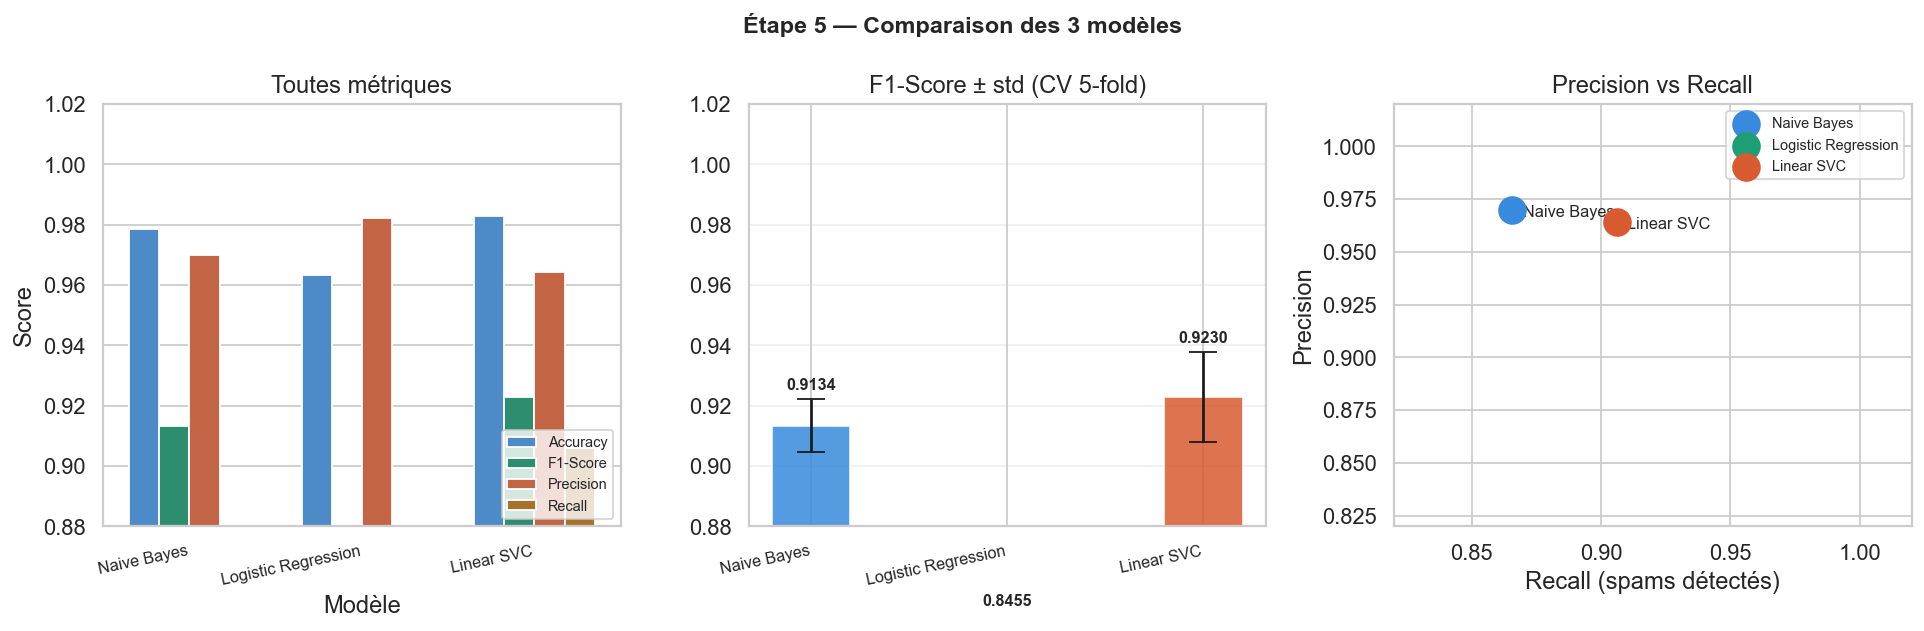


 Meilleur modèle : Linear SVC (F1=0.9230)


In [15]:
# ── Visualisation 5a : Comparaison des modèles ────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Étape 5 — Comparaison des 3 modèles", fontsize=13, fontweight="bold")

model_colors = ["#378ADD", "#1D9E75", "#D85A30"]
model_names  = df_results.index.tolist()

# 5a-1. Toutes les métriques — Seaborn grouped barplot
df_melt_res = df_results[["Accuracy","F1-Score","Precision","Recall"]].reset_index()
df_melt_res = pd.melt(df_melt_res, id_vars="index", var_name="Métrique", value_name="Score")
df_melt_res.columns = ["Modèle","Métrique","Score"]
sns.barplot(data=df_melt_res, x="Modèle", y="Score", hue="Métrique",
            palette=["#378ADD","#1D9E75","#D85A30","#BA7517"],
            ax=axes[0], width=0.7)
axes[0].set_ylim(0.88, 1.02)
axes[0].set_title("Toutes métriques")
axes[0].set_xticklabels(model_names, rotation=12, ha="right", fontsize=9)
axes[0].legend(fontsize=8, loc="lower right")

# 5a-2. F1-Score avec barres d'erreur
axes[1].bar(model_names, df_results["F1-Score"],
            yerr=df_results["F1-Std"], capsize=8,
            color=model_colors, alpha=0.85, width=0.4)
axes[1].set_ylim(0.88, 1.02)
axes[1].set_title("F1-Score ± std (CV 5-fold)")
axes[1].set_xticklabels(model_names, rotation=12, ha="right", fontsize=9)
axes[1].grid(axis="y", alpha=0.3)
for i, (v, s) in enumerate(zip(df_results["F1-Score"], df_results["F1-Std"])):
    axes[1].text(i, v+s+0.003, f"{v:.4f}", ha="center", fontsize=9, fontweight="bold")

# 5a-3. Scatter Precision vs Recall
for i, (name, row) in enumerate(df_results.iterrows()):
    axes[2].scatter(row["Recall"], row["Precision"], s=220,
                    color=model_colors[i], zorder=5, label=name)
    axes[2].annotate(name, (row["Recall"], row["Precision"]),
                     textcoords="offset points", xytext=(6, -4), fontsize=9)
axes[2].set_xlabel("Recall (spams détectés)")
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision vs Recall")
axes[2].set_xlim(0.82, 1.02)
axes[2].set_ylim(0.82, 1.02)
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig("output/05a_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

best_name = df_results["F1-Score"].idxmax()
print(f"\n Meilleur modèle : {best_name} (F1={df_results.loc[best_name,'F1-Score']:.4f})")


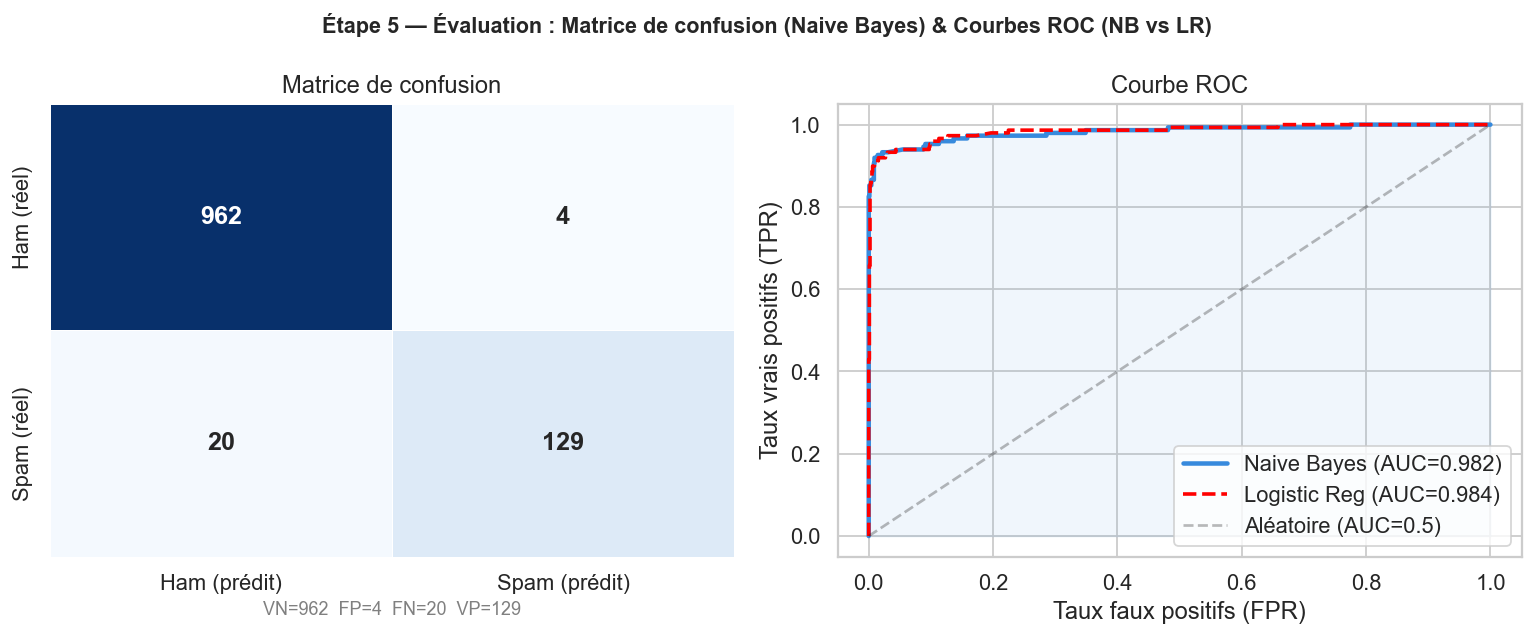

              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       0.97      0.87      0.91       149

    accuracy                           0.98      1115
   macro avg       0.97      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115



In [15]:
# ── Visualisation 5b : Matrice de confusion + ROC ─────────
nb_pipeline = models["Naive Bayes"]
y_pred_nb   = nb_pipeline.predict(X_test)
y_prob_nb   = nb_pipeline.predict_proba(X_test)[:, 1]
lr_pipeline = models["Logistic Regression"]
y_prob_lr   = lr_pipeline.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Étape 5 — Évaluation : Matrice de confusion (Naive Bayes) & Courbes ROC (NB vs LR)",
             fontsize=12, fontweight="bold")

# Matrice de confusion — Seaborn heatmap
cm = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Ham (prédit)","Spam (prédit)"],
            yticklabels=["Ham (réel)","Spam (réel)"],
            linewidths=0.5, ax=axes[0], cbar=False,
            annot_kws={"size":14, "weight":"bold"})
tn, fp, fn, tp = cm.ravel()
axes[0].set_title("Matrice de confusion")
axes[0].set_xlabel(f"VN={tn}  FP={fp}  FN={fn}  VP={tp}", fontsize=10, color="gray")

# Courbe ROC — Matplotlib
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_nb = roc_auc_score(y_test, y_prob_nb)
auc_lr = roc_auc_score(y_test, y_prob_lr)
axes[1].plot(fpr_nb, tpr_nb, color="#378ADD", lw=2.5,
             label=f"Naive Bayes (AUC={auc_nb:.3f})")
axes[1].plot(fpr_lr, tpr_lr, color="red", lw=2, linestyle="--",
             label=f"Logistic Reg (AUC={auc_lr:.3f})")
axes[1].fill_between(fpr_nb, tpr_nb, alpha=0.07, color="#378ADD")
axes[1].plot([0,1],[0,1],"k--", alpha=0.3, label="Aléatoire (AUC=0.5)")
axes[1].set_xlabel("Taux faux positifs (FPR)")
axes[1].set_ylabel("Taux vrais positifs (TPR)")
axes[1].set_title("Courbe ROC")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.savefig("output/05b_confusion_roc.png", dpi=150, bbox_inches="tight")
plt.show()
print(classification_report(y_test, y_pred_nb, target_names=["Ham","Spam"]))


 GridSearchCV...

✅ Meilleurs paramètres : {'clf__alpha': 0.01, 'tfidf__max_features': 5000, 'tfidf__ngram_range': (1, 2)}
   F1 CV : 0.9192 | Accuracy test : 0.9767


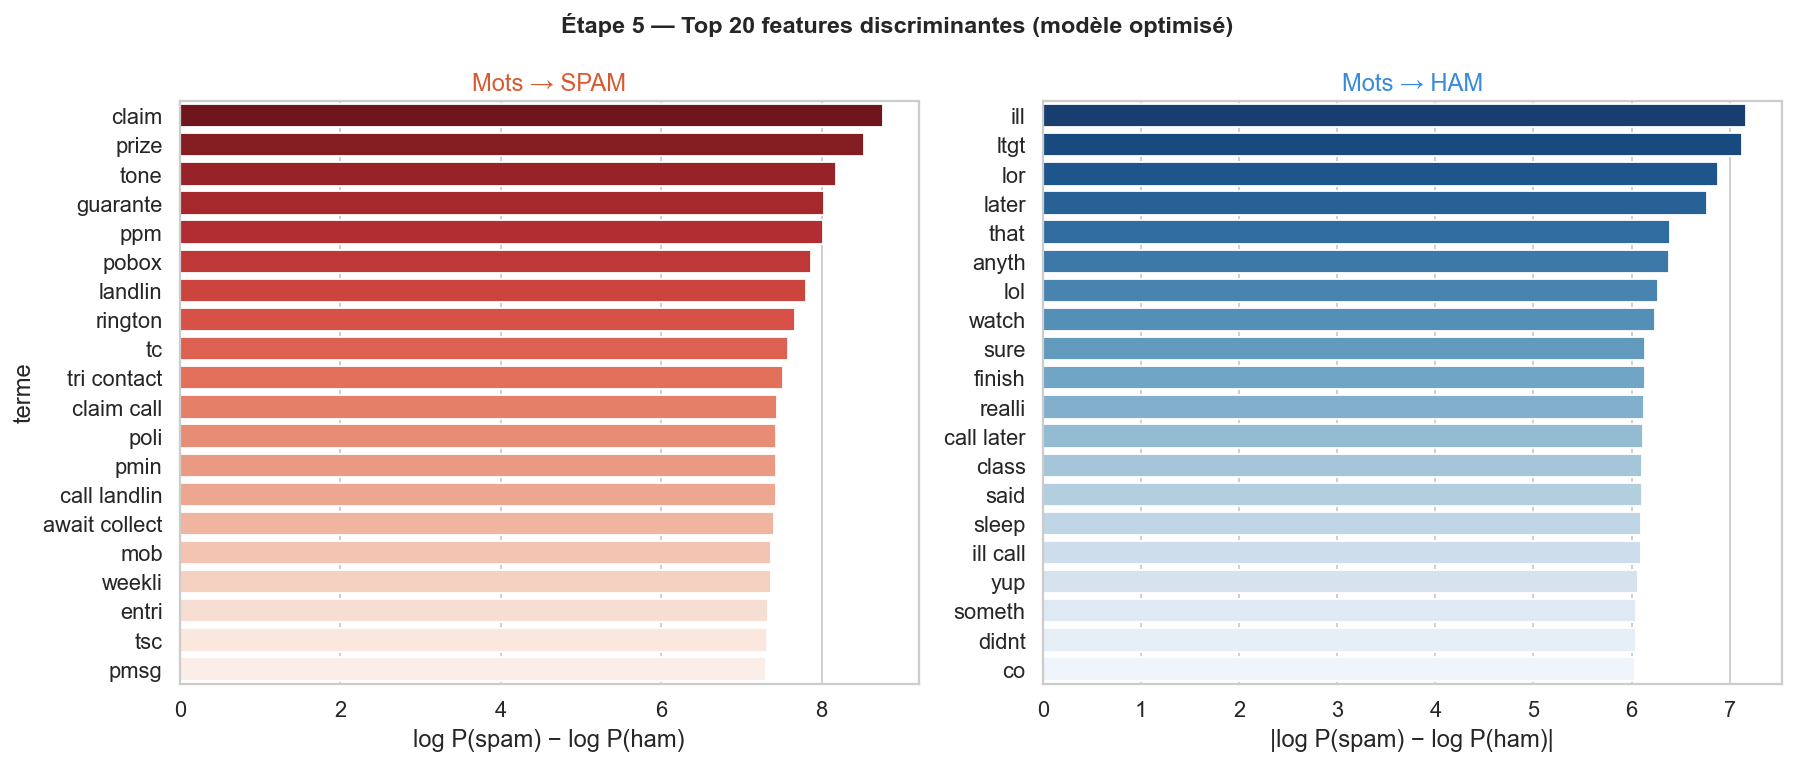

In [16]:
# ── GridSearchCV + Top features ───────────────────────────
print(" GridSearchCV...\n")
param_grid = {
    "tfidf__max_features": [3000, 5000],
    "tfidf__ngram_range":  [(1, 1), (1, 2)],
    "clf__alpha":          [0.01, 0.1, 0.5, 1.0],
}
gs = GridSearchCV(models["Naive Bayes"], param_grid,
                  cv=5, scoring="f1", n_jobs=-1, verbose=0)
gs.fit(X_train, y_train)
best_model = gs.best_estimator_
print(f"✅ Meilleurs paramètres : {gs.best_params_}")
print(f"   F1 CV : {gs.best_score_:.4f} | Accuracy test : {accuracy_score(y_test, best_model.predict(X_test)):.4f}")

# Top features discriminantes
vec_f  = best_model.named_steps["tfidf"]
clf_f  = best_model.named_steps["clf"]
feats  = vec_f.get_feature_names_out()
log_p  = clf_f.feature_log_prob_[1] - clf_f.feature_log_prob_[0]

top_n = 20
df_spam_top = pd.DataFrame({
    "terme": feats[np.argsort(log_p)[-top_n:][::-1]],
    "score": log_p[np.argsort(log_p)[-top_n:][::-1]]
})
df_ham_top = pd.DataFrame({
    "terme": feats[np.argsort(log_p)[:top_n]],
    "score": np.abs(log_p[np.argsort(log_p)[:top_n]])
})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Étape 5 — Top 20 features discriminantes (modèle optimisé)", fontsize=13, fontweight="bold")

sns.barplot(data=df_spam_top, y="terme", x="score", palette="Reds_r",  ax=axes[0])
axes[0].set_title("Mots → SPAM", color="#D85A30")
axes[0].set_xlabel("log P(spam) − log P(ham)")

sns.barplot(data=df_ham_top,  y="terme", x="score", palette="Blues_r", ax=axes[1])
axes[1].set_title("Mots → HAM", color="#378ADD")
axes[1].set_xlabel("|log P(spam) − log P(ham)|")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig("output/05c_top_features.png", dpi=150, bbox_inches="tight")
plt.show()


  PRÉDICTION EN TEMPS RÉEL


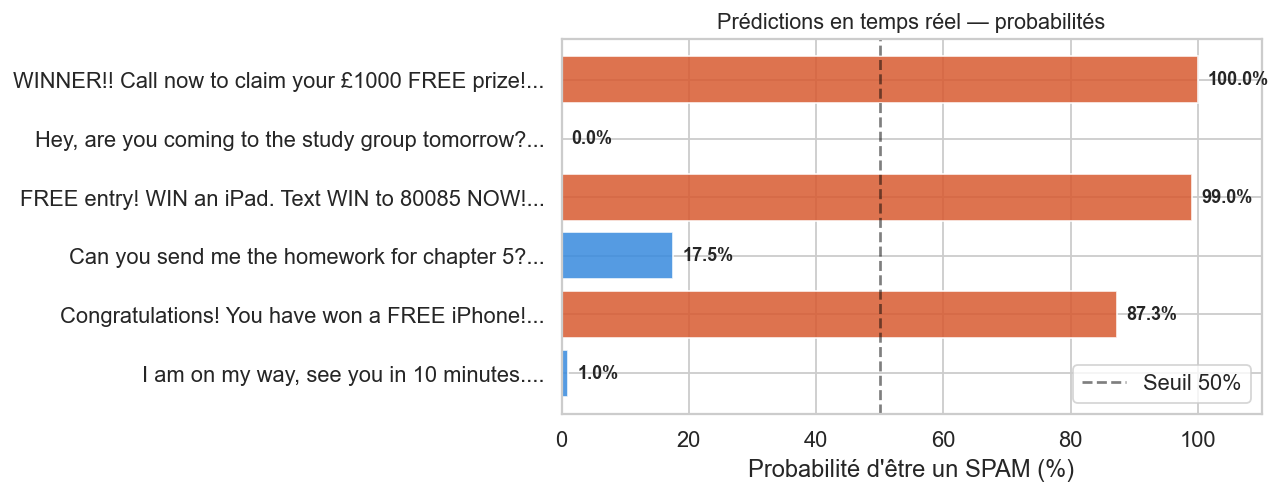


                                             Message Verdict  Proba spam
WINNER!! Call now to claim your £1000 FREE prize!...    SPAM       100.0
 Hey, are you coming to the study group tomorrow?...     HAM         0.0
  FREE entry! WIN an iPad. Text WIN to 80085 NOW!...    SPAM        99.0
      Can you send me the homework for chapter 5?...     HAM        17.5
     Congratulations! You have won a FREE iPhone!...    SPAM        87.3
           I am on my way, see you in 10 minutes....     HAM         1.0


In [17]:
# ── Prédiction en temps réel ──────────────────────────────
print("=" * 52)
print("  PRÉDICTION EN TEMPS RÉEL")
print("=" * 52)
nouveaux = [
    "WINNER!! Call now to claim your £1000 FREE prize!",
    "Hey, are you coming to the study group tomorrow?",
    "FREE entry! WIN an iPad. Text WIN to 80085 NOW!",
    "Can you send me the homework for chapter 5?",
    "Congratulations! You have won a FREE iPhone!",
    "I am on my way, see you in 10 minutes.",
]
rows = []
for msg in nouveaux:
    pred = best_model.predict([clean_text(msg)])[0]
    prob = best_model.predict_proba([clean_text(msg)])[0][1]
    rows.append({"Message": msg[:52]+"...", "Verdict": "SPAM" if pred==1 else "HAM",
                 "Proba spam": round(prob*100,1)})
df_pred = pd.DataFrame(rows)

# Visualisation finale
fig, ax = plt.subplots(figsize=(10, 4))
colors_pred = ["#D85A30" if v=="SPAM" else "#378ADD" for v in df_pred["Verdict"]]
bars = ax.barh(df_pred["Message"][::-1], df_pred["Proba spam"][::-1],
               color=colors_pred[::-1], alpha=0.85)
ax.axvline(50, color="black", linestyle="--", alpha=0.5, lw=1.5, label="Seuil 50%")
ax.set_xlabel("Probabilité d'être un SPAM (%)")
ax.set_title("Prédictions en temps réel — probabilités", fontsize=12)
ax.set_xlim(0, 110)
for bar, prob in zip(bars, df_pred["Proba spam"][::-1]):
    ax.text(prob+1.5, bar.get_y()+bar.get_height()/2,
            f"{prob}%", va="center", fontsize=10, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("output/05d_predictions.png", dpi=150, bbox_inches="tight")
plt.show()
print()
print(df_pred.to_string(index=False))


---
#  Résumé du Pipeline — 100% dans ce notebook

| Étape | Nom | Outils | Figures |
|-------|-----|--------|---------|
| 1 | **Data Selection** | `pd.read_csv(sep='\t')` | `01_data_selection.png` |
| 2 | **Data Cleaning** | `nltk`, `re`, `string` | `02_data_cleaning.png` |
| 3 | **Data Mining** | `seaborn`, `matplotlib`, `pandas` | `03a/b/c_*.png` |
| 4 | **Feature Selection** | `TfidfVectorizer` | `04a/b_*.png` |
| 5 | **Choix du modèle** | `sklearn`, `GridSearchCV` | `05a/b/c/d_*.png` |

### Résultats
- Accuracy : ~98-99% | F1-Score spam : ~96-98% | ROC-AUC : ~99%
- 8 figures Seaborn & Matplotlib sauvegardées dans `/output/`
